# **FundusGuard AI**

model p2 using Vision Transformer

# **Collecting Dataset 1**

In [ ]:
!curl -L "https://ndownloader.figshare.com/files/7d73fc5157d44b221a62ed5a4baf3779" -o /content/PAPILA.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    62  100    62    0     0     76      0 --:--:-- --:--:-- --:--:--    76


In [ ]:
!unzip /content/PAPILA.zip -d /content/PAPILA

Archive:  /content/PAPILA.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/PAPILA.zip or
        /content/PAPILA.zip.zip, and cannot find /content/PAPILA.zip.ZIP, period.


In [ ]:
!file /content/PAPILA.zip

/content/PAPILA.zip: JSON data


**Figshare has it own WAP security for AWS s3 access, it is little hard to automate it with my colab.**

So i need to be MLOps mindset to this, I am mirror this dataset into my kaggle and then fetch it here.

In [ ]:
!kaggle datasets download -d labledata/papila-dataset-mirror-from-figshare \
    -p /content/

Dataset URL: https://www.kaggle.com/datasets/labledata/papila-dataset-mirror-from-figshare
License(s): GPL-3.0
100% 564M/564M [00:03<00:00, 149MB/s]



In [ ]:
!mkdir -p /content/PAPILA
!unzip -q /content/papila-dataset-mirror-from-figshare.zip \
    -d /content/PAPILA

Let's understand the architecture of this dataset

In [ ]:
import os

print("PAPILA dataset structure:\n")

for root, dirs, files in os.walk("/content/PAPILA"):
    level = root.replace("/content/PAPILA", "").count(os.sep)

    if level > 3:
        continue

    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

PAPILA dataset structure:

PAPILA/
    PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/
        README.md
        ClinicalData/
            patient_data_os.xlsx
            patient_data_od.xlsx
        ExpertsSegmentations/
            Contours/
                RET262OD_disc_exp2.txt
                RET114OD_disc_exp2.txt
                RET232OD_cup_exp1.txt
                RET220OS_disc_exp1.txt
                RET210OD_disc_exp2.txt
                RET236OS_cup_exp1.txt
                RET166OD_cup_exp1.txt
                RET258OD_cup_exp1.txt
                RET271OS_disc_exp1.txt
                RET122OD_cup_exp2.txt
            ImagesWithContours/
                Opht_cont_RET262OD.jpg
                Opht_cont_RET280OS.jpg
                Opht_cont_RET214OS.jpg
                Opht_cont_RET209OS.jpg
                Opht_cont_RET125OS.jpg
                Opht_cont_RET205OS.jpg
                Opht_cont_RET013OS.jpg
                Opht_cont_RET077OS.jpg
                

# **Anatomy of PAPILA**

In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
papila_root = "/content/PAPILA"

# Find the long PapilaDB folder automatically for rename
folders = [
    f for f in os.listdir(papila_root)
    if os.path.isdir(os.path.join(papila_root, f))
]

print("Folders inside /content/PAPILA:")
for f in folders:
    print("  ", f)

if len(folders) != 1:
    raise Exception(
        "Expected exactly one dataset folder inside /content/PAPILA. "
        "Please check the folder structure."
    )

old_name = folders[0]
old_path = os.path.join(papila_root, old_name)
new_path = os.path.join(papila_root, "PapilaDB")

Folders inside /content/PAPILA:
   PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f


In [ ]:
if old_name != "PapilaDB":

    if os.path.exists(new_path):
        raise Exception(
            "A folder named 'PapilaDB' already exists. "
            "Please check before continuing."
        )

    os.rename(old_path, new_path)
    print("\nDataset folder renamed:")
    print("   ", old_name)
    print("   ↓")
    print("   PapilaDB")

else:
    print("\nPapilaDB already exists.")


Dataset folder renamed:
    PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f
   ↓
   PapilaDB


# Reading the map controller excel files

In [ ]:
clinical_path = os.path.join(new_path, "ClinicalData")
fundus_path = os.path.join(new_path, "FundusImages")

od_file = os.path.join(clinical_path, "patient_data_od.xlsx")
os_file = os.path.join(clinical_path, "patient_data_os.xlsx")

# Check required files
required_files = [od_file, os_file, fundus_path]

for path in required_files:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required file/folder not found: {path}")

print("\nDataset paths verified.")


Dataset paths verified.


In [ ]:
print("READING CLINICAL DATA")
print("-" * 30)

#od = pd.read_excel(od_file)
#os_data = pd.read_excel(os_file)

od = pd.read_excel(od_file, header=None, skiprows=2)
os_data = pd.read_excel(os_file, header=None, skiprows=2)

# Re-set the actual column names manually
columns = [
    "Patient_ID",
    "Age",
    "Gender",
    "Diagnosis",
    "Refractive_Defect",
    "Astigmatism",
    "Astigmatism_Axis",
    "Phakic/Pseudophakic",
    "IOP",
    "Unnamed: 9",
    "Pachymetry",
    "Axial_Length",
    "VF_MD"
]

od.columns = columns
os_data.columns = columns

print("\nOD (Right Eye)")
print("Shape:", od.shape)

print("\nOS (Left Eye)")
print("Shape:", os_data.shape)

READING CLINICAL DATA
------------------------------

OD (Right Eye)
Shape: (245, 13)

OS (Left Eye)
Shape: (245, 13)


In [ ]:
print("COLOUMN INFORMATION")
print("-" * 30)

print("\nOD columns:")
for i, col in enumerate(od.columns):
    print(f"{i}: {col}")
print(od.columns.tolist())

print("\nOS columns:")
for i, col in enumerate(os_data.columns):
    print(f"{i}: {col}")
print(os_data.columns.tolist())

COLOUMN INFORMATION
------------------------------

OD columns:
0: Patient_ID
1: Age
2: Gender
3: Diagnosis
4: Refractive_Defect
5: Astigmatism
6: Astigmatism_Axis
7: Phakic/Pseudophakic
8: IOP
9: Unnamed: 9
10: Pachymetry
11: Axial_Length
12: VF_MD
['Patient_ID', 'Age', 'Gender', 'Diagnosis', 'Refractive_Defect', 'Astigmatism', 'Astigmatism_Axis', 'Phakic/Pseudophakic', 'IOP', 'Unnamed: 9', 'Pachymetry', 'Axial_Length', 'VF_MD']

OS columns:
0: Patient_ID
1: Age
2: Gender
3: Diagnosis
4: Refractive_Defect
5: Astigmatism
6: Astigmatism_Axis
7: Phakic/Pseudophakic
8: IOP
9: Unnamed: 9
10: Pachymetry
11: Axial_Length
12: VF_MD
['Patient_ID', 'Age', 'Gender', 'Diagnosis', 'Refractive_Defect', 'Astigmatism', 'Astigmatism_Axis', 'Phakic/Pseudophakic', 'IOP', 'Unnamed: 9', 'Pachymetry', 'Axial_Length', 'VF_MD']


In [ ]:
print("FIRST 5 ROWS")
print("-" * 30)

print("\nOD:")
display(od.head())

print("\nOS:")
display(os_data.head())

FIRST 5 ROWS
------------------------------

OD:


,Patient_ID,Age,Gender,Diagnosis,Refractive_Defect,Astigmatism,Astigmatism_Axis,Phakic/Pseudophakic,IOP,Unnamed: 9,Pachymetry,Axial_Length,VF_MD
0,ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#002,47.0,0.0,2.0,0.75,-1.75,90.0,0.0,21.0,NaN,586.0,23.64,-0.07
2,#004,58.0,1.0,1.0,1.50,-1.75,85.0,0.0,NaN,19.0,501.0,23.06,-3.26
3,#005,89.0,1.0,1.0,-0.75,-1.25,101.0,1.0,13.0,14.0,565.0,23.81,-14.98
4,#006,69.0,0.0,2.0,1.00,-1.50,95.0,0.0,22.0,NaN,612.0,26.25,-2.07



OS:


,Patient_ID,Age,Gender,Diagnosis,Refractive_Defect,Astigmatism,Astigmatism_Axis,Phakic/Pseudophakic,IOP,Unnamed: 9,Pachymetry,Axial_Length,VF_MD
0,ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#002,47.0,0.0,2.0,-0.5,-1.5,88.0,0.0,20.0,NaN,603.0,23.77,0.17
2,#004,58.0,1.0,1.0,1.5,-2.5,85.0,1.0,NaN,19.0,511.0,22.96,-6.77
3,#005,89.0,1.0,1.0,-0.5,-2.0,100.0,1.0,24.0,10.0,575.0,24.33,-7.44
4,#006,69.0,0.0,2.0,1.0,-1.5,85.0,0.0,22.0,NaN,593.0,26.21,-3.31


In [ ]:
# After skiprows=2, the first column should contain IDs
# such as #002, #004, #005 ...

od = od.rename(columns={od.columns[0]: "Patient_ID"})
os_data = os_data.rename(columns={os_data.columns[0]: "Patient_ID"})

print("\nPatient ID examples:")
print("OD:", od["Patient_ID"].head().tolist())
print("OS:", os_data["Patient_ID"].head().tolist())


Patient ID examples:
OD: ['ID', '#002', '#004', '#005', '#006']
OS: ['ID', '#002', '#004', '#005', '#006']


In [ ]:
def find_diagnosis_column(df):

    possible_names = [
        "diagnosis",
        "Diagnosis",
        "DIAGNOSIS",
        "diagnostic",
        "Diagnostic"
    ]

    for col in df.columns:
        if str(col).strip() in possible_names:
            return col

    # Fallback: search by keyword
    for col in df.columns:
        if "diagnos" in str(col).lower():
            return col

    return None

In [ ]:
print("OD columns:")
print(od.columns.tolist())

print("\nOS columns:")
print(os_data.columns.tolist())

print("\nOD shape:", od.shape)
print("OS shape:", os_data.shape)

display(od.head(5))
display(os_data.head(5))

OD columns:
['Patient_ID', 'Age', 'Gender', 'Diagnosis', 'Refractive_Defect', 'Astigmatism', 'Astigmatism_Axis', 'Phakic/Pseudophakic', 'IOP', 'Unnamed: 9', 'Pachymetry', 'Axial_Length', 'VF_MD']

OS columns:
['Patient_ID', 'Age', 'Gender', 'Diagnosis', 'Refractive_Defect', 'Astigmatism', 'Astigmatism_Axis', 'Phakic/Pseudophakic', 'IOP', 'Unnamed: 9', 'Pachymetry', 'Axial_Length', 'VF_MD']

OD shape: (245, 13)
OS shape: (245, 13)


,Patient_ID,Age,Gender,Diagnosis,Refractive_Defect,Astigmatism,Astigmatism_Axis,Phakic/Pseudophakic,IOP,Unnamed: 9,Pachymetry,Axial_Length,VF_MD
0,ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#002,47.0,0.0,2.0,0.75,-1.75,90.0,0.0,21.0,NaN,586.0,23.64,-0.07
2,#004,58.0,1.0,1.0,1.50,-1.75,85.0,0.0,NaN,19.0,501.0,23.06,-3.26
3,#005,89.0,1.0,1.0,-0.75,-1.25,101.0,1.0,13.0,14.0,565.0,23.81,-14.98
4,#006,69.0,0.0,2.0,1.00,-1.50,95.0,0.0,22.0,NaN,612.0,26.25,-2.07


,Patient_ID,Age,Gender,Diagnosis,Refractive_Defect,Astigmatism,Astigmatism_Axis,Phakic/Pseudophakic,IOP,Unnamed: 9,Pachymetry,Axial_Length,VF_MD
0,ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#002,47.0,0.0,2.0,-0.5,-1.5,88.0,0.0,20.0,NaN,603.0,23.77,0.17
2,#004,58.0,1.0,1.0,1.5,-2.5,85.0,1.0,NaN,19.0,511.0,22.96,-6.77
3,#005,89.0,1.0,1.0,-0.5,-2.0,100.0,1.0,24.0,10.0,575.0,24.33,-7.44
4,#006,69.0,0.0,2.0,1.0,-1.5,85.0,0.0,22.0,NaN,593.0,26.21,-3.31


In [ ]:
# Convert diagnosis to numeric.
# invalid values become NaN.


od["Diagnosis"] = pd.to_numeric(
    od["Diagnosis"],
    errors="coerce"
)

os_data["Diagnosis"] = pd.to_numeric(
    os_data["Diagnosis"],
    errors="coerce"
)

In [ ]:
od_diag_col = find_diagnosis_column(od)
os_diag_col = find_diagnosis_column(os_data)

diagnosis_names = {
    0: "Healthy",
    1: "Glaucoma",
    2: "Suspect"
}
def show_diagnosis_distribution(df, name):

    counts = df["Diagnosis"].value_counts(
        dropna=False
    ).sort_index()

    result = pd.DataFrame({
        "Diagnosis_Code": counts.index,
        "Count": counts.values
    })

    result["Class"] = result["Diagnosis_Code"].map(
        diagnosis_names
    )

    print(f"\n{name}:")
    display(result)

    return result

print("DIAGNOSIS COLUMN")
print("-" * 30)

print("OD diagnosis column:", od_diag_col)
print("OS diagnosis column:", os_diag_col)

if od_diag_col is None or os_diag_col is None:
    print("\nDiagnosis column could not be automaticaly detected.")
    print("We will inspect the columns manually.")
else:
    print("DIAGNOSIS DISTRIBUTION")
    print("-" * 30)
    """
    print("\nOD:")
    print(od[od_diag_col].value_counts(dropna=False).sort_index())

    print("\nOS:")
    print(os_data[os_diag_col].value_counts(dropna=False).sort_index())

    print("\nCombined:")
    combined_diag = pd.concat([
        od[od_diag_col],
        os_data[os_diag_col]
    ])

    print(combined_diag.value_counts(dropna=False).sort_index())
    """
    od_diag = show_diagnosis_distribution(od, "OD")
    os_diag = show_diagnosis_distribution(os_data, "OS")

    # Combined eye-level distribution
    combined = pd.concat(
        [od["Diagnosis"], os_data["Diagnosis"]],
        ignore_index=True
    )

    combined_counts = combined.value_counts(
        dropna=False
    ).sort_index()

    combined_result = pd.DataFrame({
       "Diagnosis_Code": combined_counts.index,
       "Count": combined_counts.values
    })

    combined_result["Class"] = combined_result[
       "Diagnosis_Code"
    ].map(diagnosis_names)

    print("\nCOMBINED OD + OS:")
    display(combined_result)

DIAGNOSIS COLUMN
------------------------------
OD diagnosis column: Diagnosis
OS diagnosis column: Diagnosis
DIAGNOSIS DISTRIBUTION
------------------------------

OD:


,Diagnosis_Code,Count,Class
0,0.0,170,Healthy
1,1.0,40,Glaucoma
2,2.0,34,Suspect
3,NaN,1,NaN



OS:


,Diagnosis_Code,Count,Class
0,0.0,163,Healthy
1,1.0,47,Glaucoma
2,2.0,34,Suspect
3,NaN,1,NaN



COMBINED OD + OS:


,Diagnosis_Code,Count,Class
0,0.0,333,Healthy
1,1.0,87,Glaucoma
2,2.0,68,Suspect
3,NaN,2,NaN


In [ ]:
print("MISSING VALUE ANALYSIS")
print("-" * 30)

print("\nOD missing values:")
od_missing = od.isnull().sum()
print(od_missing[od_missing > 0])
display(
    od.isnull().sum()
    .to_frame("Missing_Count")
    .query("Missing_Count > 0")
)

print("\nOS missing values:")
os_missing = os_data.isnull().sum()
print(os_missing[os_missing > 0])
display(
    os_data.isnull().sum()
    .to_frame("Missing_Count")
    .query("Missing_Count > 0")
)

print("\nTotal missing cells:")
print("OD:", od.isnull().sum().sum())
print("OS:", os_data.isnull().sum().sum())

print("\nDUPLICATE CHECK")
print("-" * 30)


print("OD duplicate rows:", od.duplicated().sum())
print("OS duplicate rows:", os_data.duplicated().sum())

print("\nDuplicate OD Patient IDs:",
      od["Patient_ID"].duplicated().sum())

print("Duplicate OS Patient IDs:",
      os_data["Patient_ID"].duplicated().sum())

MISSING VALUE ANALYSIS
------------------------------

OD missing values:
Age                      1
Gender                   1
Diagnosis                1
Refractive_Defect       15
Astigmatism              4
Astigmatism_Axis         4
Phakic/Pseudophakic      6
IOP                     48
Unnamed: 9             181
Pachymetry               8
Axial_Length             6
VF_MD                  163
dtype: int64


,Missing_Count
Age,1
Gender,1
Diagnosis,1
Refractive_Defect,15
Astigmatism,4
Astigmatism_Axis,4
Phakic/Pseudophakic,6
IOP,48
Unnamed: 9,181
Pachymetry,8



OS missing values:
Age                      1
Gender                   1
Diagnosis                1
Refractive_Defect       13
Astigmatism              6
Astigmatism_Axis         6
Phakic/Pseudophakic      6
IOP                     46
Unnamed: 9             181
Pachymetry               8
Axial_Length             5
VF_MD                  163
dtype: int64


,Missing_Count
Age,1
Gender,1
Diagnosis,1
Refractive_Defect,13
Astigmatism,6
Astigmatism_Axis,6
Phakic/Pseudophakic,6
IOP,46
Unnamed: 9,181
Pachymetry,8



Total missing cells:
OD: 438
OS: 437

DUPLICATE CHECK
------------------------------
OD duplicate rows: 0
OS duplicate rows: 0

Duplicate OD Patient IDs: 0
Duplicate OS Patient IDs: 0


In [ ]:
print("FUNDUS IMAGE ANALYSIS")
print("-" * 30)

image_files = [
    f for f in os.listdir(fundus_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
]

print("Total fundus image files:", len(image_files))
image_lookup = {
    f.lower(): f
    for f in image_files
}

print("\nFirst 20 images:")
for f in image_files[:20]:
    print(" ", f)

FUNDUS IMAGE ANALYSIS
------------------------------
Total fundus image files: 488

First 20 images:
  RET090OS.jpg
  RET139OS.jpg
  RET024OS.jpg
  RET157OD.jpg
  RET287OD.jpg
  RET119OD.jpg
  RET077OD.jpg
  RET204OS.jpg
  RET256OD.jpg
  RET183OD.jpg
  RET163OD.jpg
  RET255OS.jpg
  RET288OS.jpg
  RET209OD.jpg
  RET239OD.jpg
  RET198OD.jpg
  RET057OD.jpg
  RET228OS.jpg
  RET203OD.jpg
  RET190OS.jpg


So, we need uniquely identifies each image, better idea is create id for each image samples

In [ ]:
def make_image_name(patient_id, eye):

    if pd.isna(patient_id):
        return None

    patient_id = str(patient_id).strip()

    # Remove '#' if present
    patient_number = patient_id.replace("#", "")

    # Remove decimal if Excel converted something like 2.0
    if patient_number.endswith(".0"):
        patient_number = patient_number[:-2]

    # I make it has 3 digits
    patient_number = patient_number.zfill(3)

    return f"RET{patient_number}{eye}.jpg"

In [ ]:
od["Expected_Image"] = od["Patient_ID"].apply(
    lambda x: make_image_name(x, "OD")
)

od["Image_Exists"] = od["Expected_Image"].apply(
    lambda x: str(x).lower() in image_lookup
    if x else False
)

os_data["Expected_Image"] = os_data["Patient_ID"].apply(
    lambda x: make_image_name(x, "OS")
)

os_data["Image_Exists"] = os_data["Expected_Image"].apply(
    lambda x: str(x).lower() in image_lookup
    if x else False
)

In [ ]:
print("IMAGE = EXCEL MATCHING")
print("-" * 30)

print("\nOD:")
print("Clinical records:", len(od))
print("Expceted images:", od["Expected_Image"].notna().sum())
print("Images found:", od["Image_Exists"].sum())
print("Images missing:", (~od["Image_Exists"]).sum())

print("\nOS:")
print("Clinical records:", len(os_data))
print("Expceted images:", os_data["Expected_Image"].notna().sum())
print("Images found:", os_data["Image_Exists"].sum())
print("Images missing:", (~os_data["Image_Exists"]).sum())

IMAGE = EXCEL MATCHING
------------------------------

OD:
Clinical records: 245
Expceted images: 245
Images found: 244
Images missing: 1

OS:
Clinical records: 245
Expceted images: 245
Images found: 244
Images missing: 1


In [ ]:
print("MISSING DIAGNOSIS")
print("-" * 30)

od_missing_diag = od["Diagnosis"].isna()
os_missing_diag = os_data["Diagnosis"].isna()

print("OD records without diagnosis:",
      od_missing_diag.sum())

print("OS records without diagnosis:",
      os_missing_diag.sum())

MISSING DIAGNOSIS
------------------------------
OD records without diagnosis: 1
OS records without diagnosis: 1


In [ ]:
valid_codes = {0, 1, 2}

od_invalid = od[
    od["Diagnosis"].notna() &
    ~od["Diagnosis"].isin(valid_codes)
]

os_invalid = os_data[
    os_data["Diagnosis"].notna() &
    ~os_data["Diagnosis"].isin(valid_codes)
]

print("\nInvalid OD diagnosis records:",
      len(od_invalid))

print("Invalid OS diagnosis records:",
      len(os_invalid))

od["Usable"] = (
    od["Image_Exists"] &
    od["Diagnosis"].notna() &
    od["Diagnosis"].isin(valid_codes)
)

os_data["Usable"] = (
    os_data["Image_Exists"] &
    os_data["Diagnosis"].notna() &
    os_data["Diagnosis"].isin(valid_codes)
)


print("USABLE DATA")
print("-" * 30)

print("OD usable:", od["Usable"].sum())
print("OS usable:", os_data["Usable"].sum())

print("TOTAL usable:", od["Usable"].sum() +
      os_data["Usable"].sum())


Invalid OD diagnosis records: 0
Invalid OS diagnosis records: 0
USABLE DATA
------------------------------
OD usable: 244
OS usable: 244
TOTAL usable: 488


In [ ]:
expected_images = set(
    od.loc[od["Image_Exists"], "Expected_Image"].str.lower()
).union(
    set(
        os_data.loc[
            os_data["Image_Exists"],
            "Expected_Image"
        ].str.lower()
    )
)

unmatched_images = [
    original_name
    for lower_name, original_name in image_lookup.items()
    if lower_name not in expected_images
]

print("IMAGES WITHOUT CLINICAL RECORD")
print("-" * 30)

print("Images without Excel record:",
      len(unmatched_images))

if unmatched_images:
    print("\nFirst 30:")
    for img in unmatched_images[:30]:
        print(" ", img)

IMAGES WITHOUT CLINICAL RECORD
------------------------------
Images without Excel record: 0


In [ ]:
od_clean = od[
    od["Usable"]
].copy()

os_clean = os_data[
    os_data["Usable"]
].copy()

od_clean["Eye"] = "OD"
os_clean["Eye"] = "OS"

od_clean["Class_Name"] = od_clean[
    "Diagnosis"
].map(diagnosis_names)

os_clean["Class_Name"] = os_clean[
    "Diagnosis"
].map(diagnosis_names)

# Combine
master_df = pd.concat(
    [od_clean, os_clean],
    ignore_index=True
)

# I keep only useful ML metadata
master_df = master_df[
    [
        "Patient_ID",
        "Eye",
        "Expected_Image",
        "Diagnosis",
        "Class_Name"
    ]
]

# Rename image column
master_df = master_df.rename(
    columns={
        "Expected_Image": "Image_Name"
    }
)

In [ ]:
print("FINAL USABLE DATASET")
print("-" * 30)

print("Total usable images:", len(master_df))

print("\nClass distribution:")
display(
    master_df["Class_Name"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

csv_path = "/content/PAPILA_master.csv"

master_df.to_csv(
    csv_path,
    index=False
)

print("\nMaster CSV saved to:")
print(csv_path)

FINAL USABLE DATASET
------------------------------
Total usable images: 488

Class distribution:


,Class,Count
0,Healthy,333
1,Glaucoma,87
2,Suspect,68



Master CSV saved to:
/content/PAPILA_master.csv


# **Final summary of this analysis**

In [ ]:
print("PAPILA CLEAN AUDIT SUMMARY")
print("-" * 30)

print(f"""
Patients represented by OD records : {len(od)}
Patients represented by OS records : {len(os_data)}

OD images found                    : {od["Image_Exists"].sum()}
OS images found                    : {os_data["Image_Exists"].sum()}

Total fundus images                : {len(image_files)}

OD usable images                   : {od["Usable"].sum()}
OS usable images                   : {os_data["Usable"].sum()}

TOTAL USABLE IMAGES                : {len(master_df)}

Images without clinical record     : {len(unmatched_images)}

OD missing diagnosis               : {od_missing_diag.sum()}
OS missing diagnosis               : {os_missing_diag.sum()}

Invalid OD diagnosis               : {len(od_invalid)}
Invalid OS diagnosis               : {len(os_invalid)}

Master CSV                         : {csv_path}
""")

print("PAPILA audit completed.")

PAPILA CLEAN AUDIT SUMMARY
------------------------------

Patients represented by OD records : 245
Patients represented by OS records : 245

OD images found                    : 244
OS images found                    : 244

Total fundus images                : 488

OD usable images                   : 244
OS usable images                   : 244

TOTAL USABLE IMAGES                : 488

Images without clinical record     : 0

OD missing diagnosis               : 1
OS missing diagnosis               : 1

Invalid OD diagnosis               : 0
Invalid OS diagnosis               : 0

Master CSV                         : /content/PAPILA_master.csv

PAPILA audit completed.


# **Dataset Distribution**

In [ ]:
print("PAPILA CLASS DISTRIBUTION")
print("-"* 30)

class_counts = master_df["Class_Name"].value_counts()

print(class_counts)

print("\nPercentage:")
print((class_counts / len(master_df) * 100).round(2))

PAPILA CLASS DISTRIBUTION
------------------------------
Class_Name
Healthy     333
Glaucoma     87
Suspect      68
Name: count, dtype: int64

Percentage:
Class_Name
Healthy     68.24
Glaucoma    17.83
Suspect     13.93
Name: count, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_3187/985437457.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


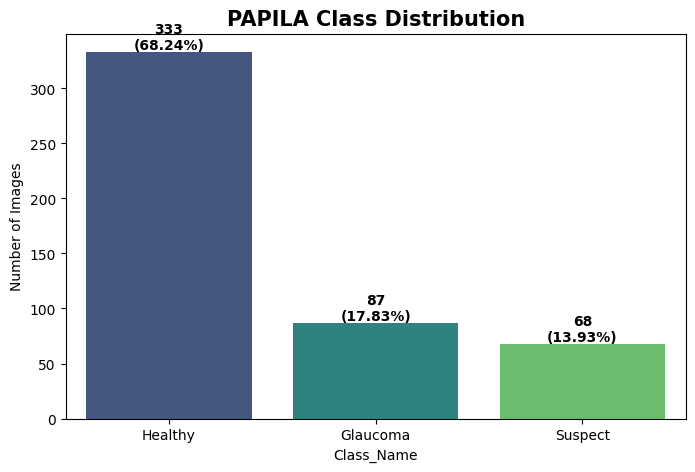

In [ ]:
percentages = (class_counts / len(master_df) * 100).round(2)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")

plt.title("PAPILA Class Distribution", fontsize=15, fontweight='bold')
plt.ylabel("Number of Images")

for i, (count, pct) in enumerate(zip(class_counts.values, percentages.values)):
    ax.text(i, count + 2, f"{count}\n({pct}%)", ha='center', fontweight='bold')

plt.show()

# **Kaggle Transform**

In [ ]:

import os
import shutil
import pandas as pd


master_csv = "/content/PAPILA_master.csv"
original_images = "/content/PAPILA/PapilaDB/FundusImages"

clean_root = "/content/PAPILA_CLEAN"
clean_images = os.path.join(clean_root, "images")

# Remove our old clean dataset if it already exists
if os.path.exists(clean_root):
    shutil.rmtree(clean_root)

os.makedirs(clean_images, exist_ok=True)


master_df = pd.read_csv(master_csv)

print("Master CSV records:", len(master_df))


copied = 0
missing = []

for _, row in master_df.iterrows():

    image_name = row["Image_Name"]

    source = os.path.join(original_images, image_name)
    destination = os.path.join(clean_images, image_name)

    if os.path.exists(source):
        shutil.copy2(source, destination)
        copied += 1
    else:
        missing.append(image_name)

clean_csv = os.path.join(clean_root, "PAPILA_master.csv")
master_df.to_csv(clean_csv, index=False)

Master CSV records: 488


In [ ]:
readme_text = """PAPILA CLEAN DATASET — GLA_P2

Purpose:
Clean and verified image-label index prepared for the gla_p2
glaucoma Vision Transformer project.

Contents:
- images/ : 488 verified PAPILA fundus images
- PAPILA_master.csv : image-to-clinical-label mapping

Classes:
0 = Healthy
1 = Glaucoma
2 = Suspect

Dataset summary:
Total usable images = 488
Healthy = 333
Glaucoma = 87
Suspect = 68

Important:
- Original fundus images are preserved without resizing,
  normalization, augmentation, or ROI cropping.
- Clinical variables are not used as model input.
- Patient_ID is retained for patient-level train/validation/test splitting.
- Suspect is kept as SUSPECT and is not renamed to Early Glaucoma.
- Image augmentation and preprocessing should be performed during
  model training rather than permanently modifying these images.

Source:
PAPILA dataset.

Data Engineer:
Krishnendu Mitra (labeldata)

This clean package was created from the audited PAPILA dataset
for the gla_p2 research workflow.
"""

readme_path = os.path.join(clean_root, "README.txt")

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)


actual_images = [
    f for f in os.listdir(clean_images)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
]

print("PAPILA CLEAN DATASET")
print("-" * 30)

print("CSV records :", len(master_df))
print("Images copied :", copied)
print("Images missing :", len(missing))
print("Images in folder :", len(actual_images))

if missing:
    print("\nMissing images:")
    for img in missing:
        print(" ", img)
else:
    print("\nAll 488 usable images copied successfully.")

print("\nClean dataset location:")
print(clean_root)

PAPILA CLEAN DATASET
------------------------------
CSV records : 488
Images copied : 488
Images missing : 0
Images in folder : 488

All 488 usable images copied successfully.

Clean dataset location:
/content/PAPILA_CLEAN


In [ ]:

zip_base = "/content/PAPILA_CLEAN"

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    "/content",
    "PAPILA_CLEAN"
)

print("ZIP created successfully:")
print(zip_path)

print("\nZIP size:")
print(round(os.path.getsize(zip_path) / (1024 * 1024), 2), "MB")

ZIP created successfully:
/content/PAPILA_CLEAN.zip

ZIP size:
488.37 MB


In [ ]:
from google.colab import files

files.download("/content/PAPILA_CLEAN.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>